# Raport: System Wspomagania Decyzji Kardiologicznych

**Autor:** [Twoje Imię i Nazwisko]

---

## 1. Opis zbioru danych

Wybranym zbiorem danych jest **Heart Disease Dataset (Cleveland)** z repozytorium UCI Machine Learning Repository.
Wybór padł na ten zbiór ze względu na czytelny podział cech, ich realny wpływ na decyzje medyczne
oraz dobrze zdefiniowaną zmienną docelową (diagnoza choroby serca: 0 = zdrowy, 1 = chory).

### Charakterystyka cech:

| Cecha | Typ | Opis |
|-------|-----|------|
| `age` | Liczbowa ciągła | Wiek pacjenta (lata) |
| `trestbps` | Liczbowa ciągła | Spoczynkowe ciśnienie krwi (mm Hg) |
| `chol` | Liczbowa ciągła | Cholesterol w surowicy (mg/dl) |
| `thalach` | Liczbowa ciągła | Maksymalne osiągnięte tętno |
| `oldpeak` | Liczbowa ciągła | Obniżenie odcinka ST wywołane wysiłkiem |
| `sex` | Kategorialna | Płeć (1 = mężczyzna, 0 = kobieta) |
| `cp` | Kategorialna | Rodzaj bólu w klatce piersiowej (1–4) |
| `fbs` | Kategorialna | Cukier na czczo > 120 mg/dl (1 = tak) |
| `restecg` | Kategorialna | Wynik EKG w spoczynku (0–2) |
| `exang` | Kategorialna | Dławica wywołana wysiłkiem (1 = tak) |
| `slope` | Kategorialna | Nachylenie odcinka ST (1–3) |
| `ca` | Kategorialna | Liczba głównych naczyń wieńcowych (0–3) |
| `thal` | Kategorialna | Wynik testu talu (3, 6, 7) |
| `target` | Zmienna docelowa | Diagnoza: 0 = zdrowy, 1 = chory |


In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Wczytanie i oczyszczenie danych
kolumny = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv('data/processed.cleveland.data', header=None, names=kolumny, na_values='?')
df = df.dropna()
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print(f"Wczytano {len(df)} rekordów. Brakujące wartości: {df.isnull().sum().sum()}")
print(f"\nRozkład klas docelowych:\n{df['target'].value_counts().rename({0: 'Zdrowy (0)', 1: 'Chory (1)'})}")
df.head()

Wczytano 297 rekordów. Brakujące wartości: 0

Rozkład klas docelowych:
target
Zdrowy (0)    160
Chory (1)     137
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2. Podział na zbiór treningowy i testowy

Zbiór dzielimy w proporcji **80% trening / 20% test** przy użyciu `train_test_split`.
Od tego momentu **wszelkie analizy, statystyki i tworzenie reguł opieramy wyłącznie
na zbiorze treningowym**, aby uniknąć wycieku danych (data leakage).


In [45]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Zbiór treningowy: {X_train.shape[0]} pacjentów")
print(f"Zbiór testowy:    {X_test.shape[0]} pacjentów")

# Przygotowanie roboczej kopii zbioru treningowego z etykietą (wyłącznie do analiz)
train_df = X_train.copy()
train_df['target'] = y_train

Zbiór treningowy: 237 pacjentów
Zbiór testowy:    60 pacjentów


## 3. Analiza Eksploracyjna — Cechy Numeryczne (EDA)

### 3.1 Statystyki opisowe dla cech numerycznych

Poniżej obliczamy podstawowe statystyki: **średnią, medianę, minimum, maksimum
i odchylenie standardowe** dla cech ciągłych na zbiorze treningowym.


In [46]:
cechy_numeryczne = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

stats = train_df[cechy_numeryczne].agg(['mean', 'median', 'min', 'max', 'std']).T
stats.columns = ['Średnia', 'Mediana', 'Min', 'Max', 'Odch. std.']
stats = stats.round(2)

print("Statystyki opisowe cech numerycznych (zbiór treningowy):")
print(stats.to_string())

Statystyki opisowe cech numerycznych (zbiór treningowy):
          Średnia  Mediana    Min    Max  Odch. std.
age         54.61     56.0   29.0   77.0        8.98
trestbps   132.25    130.0   94.0  200.0       18.04
chol       248.46    244.0  126.0  564.0       52.41
thalach    148.48    152.0   71.0  202.0       23.23
oldpeak      1.04      0.8    0.0    5.6        1.14


### 3.2 Wykresy cech numerycznych

Poniższe wykresy prezentują cechy, które najsilniej różnicują pacjentów zdrowych i chorych:

1. **Wiek (`age`)** — ryzyko choroby rośnie wyraźnie po ~55 roku życia; widoczne przesunięcie rozkładu.
2. **Maksymalne tętno (`thalach`)** — chorzy osiągają wyraźnie niższe tętno maksymalne.
3. **Obniżenie ST (`oldpeak`)** — chorzy mają wyższe wartości, co sygnalizuje niedokrwienie.
4. **Ciśnienie (`trestbps`)** — mniej różnicujące, ale ekstremalne wartości korelują z chorobą.
5. **Cholesterol (`chol`)** — niejednoznaczna, ale wysoki poziom u starszych mężczyzn podnosi ryzyko.


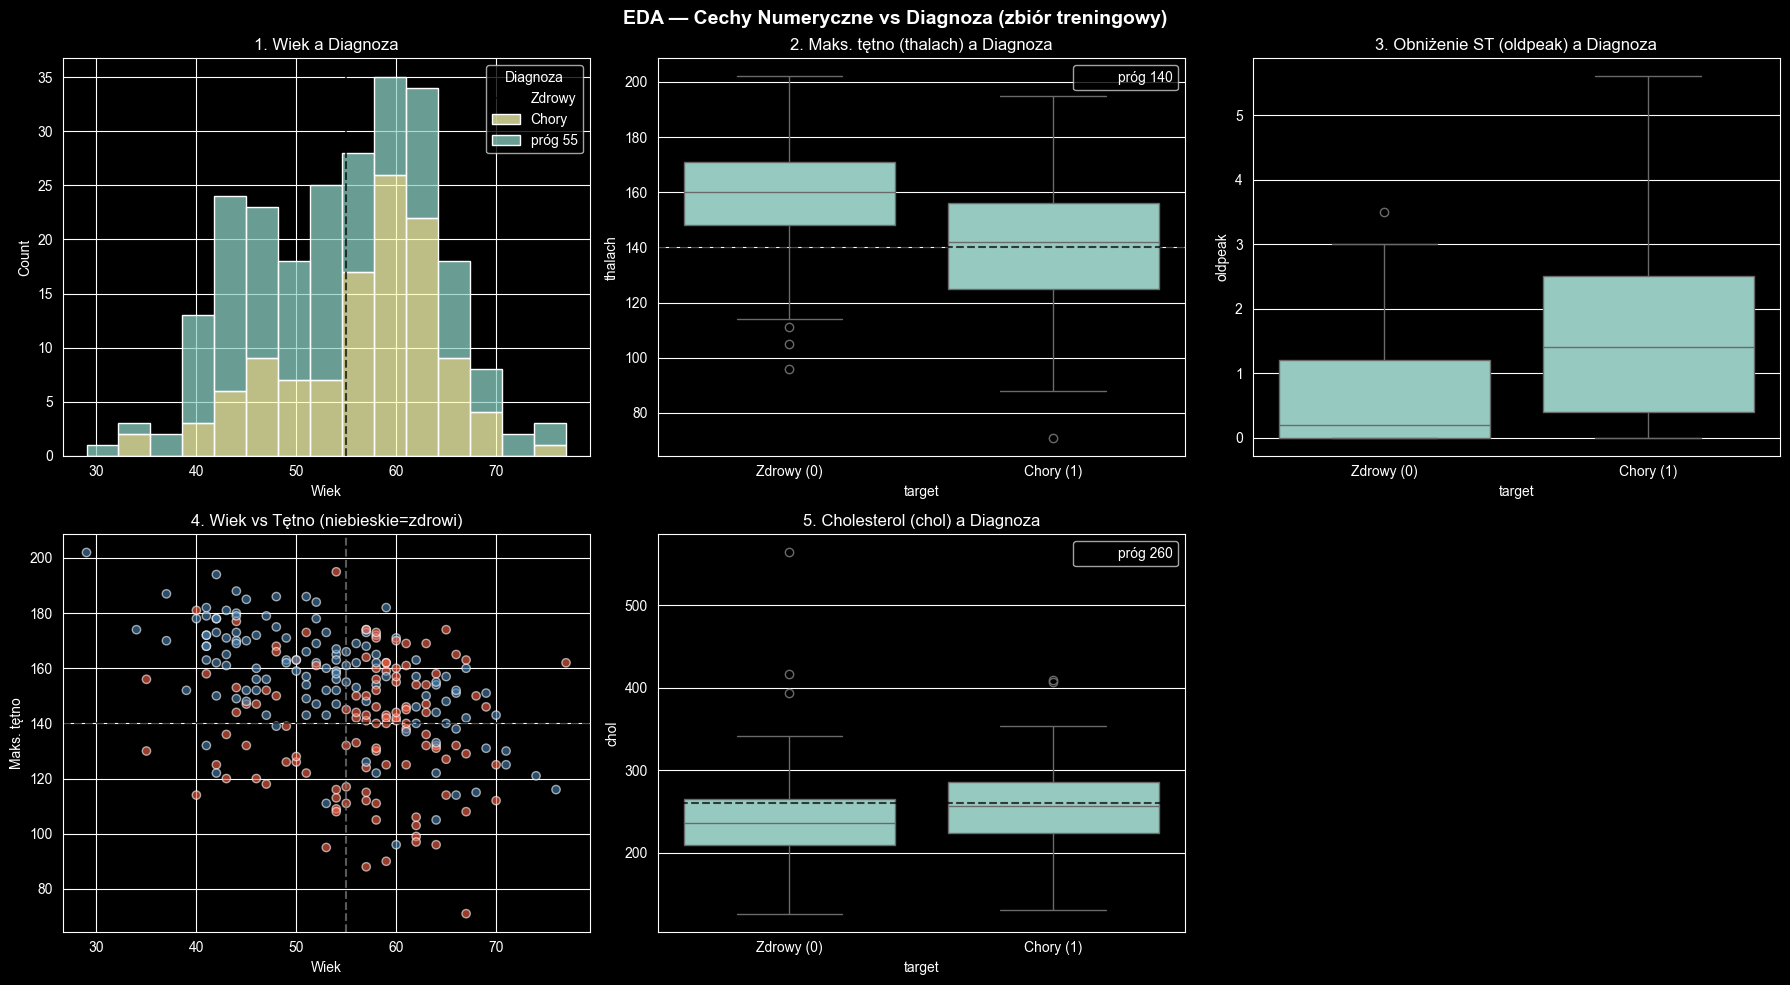

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA — Cechy Numeryczne vs Diagnoza (zbiór treningowy)', fontsize=14, fontweight='bold')

# 1. Histogram wieku
sns.histplot(data=train_df, x='age', hue='target', multiple='stack',
             bins=15, ax=axes[0,0])
axes[0,0].set_title('1. Wiek a Diagnoza')
axes[0,0].set_xlabel('Wiek')
axes[0,0].axvline(55, color='black', linestyle='--', alpha=0.7, label='próg 55 lat')
axes[0,0].legend(title='Diagnoza', labels=['Zdrowy', 'Chory', 'próg 55'])

# 2. Boxplot tętna
sns.boxplot(data=train_df, x='target', y='thalach', ax=axes[0,1])
axes[0,1].set_title('2. Maks. tętno (thalach) a Diagnoza')
axes[0,1].set_xticklabels(['Zdrowy (0)', 'Chory (1)'])
axes[0,1].axhline(140, color='black', linestyle='--', alpha=0.7, label='próg 140')
axes[0,1].legend()

# 3. Boxplot oldpeak
sns.boxplot(data=train_df, x='target', y='oldpeak', ax=axes[0,2])
axes[0,2].set_title('3. Obniżenie ST (oldpeak) a Diagnoza')
axes[0,2].set_xticklabels(['Zdrowy (0)', 'Chory (1)'])

# 4. Scatterplot wiek vs tętno
scatter_colors = train_df['target'].map({0:'steelblue', 1:'tomato'})
axes[1,0].scatter(train_df['age'], train_df['thalach'],
                  c=scatter_colors, alpha=0.6, edgecolors='w')
axes[1,0].axhline(140, color='black', linestyle='--', alpha=0.7)
axes[1,0].axvline(55, color='gray', linestyle='--', alpha=0.7)
axes[1,0].set_title('4. Wiek vs Tętno (niebieskie=zdrowi)')
axes[1,0].set_xlabel('Wiek'); axes[1,0].set_ylabel('Maks. tętno')

# 5. Boxplot cholesterol
sns.boxplot(data=train_df, x='target', y='chol', ax=axes[1,1])
axes[1,1].set_title('5. Cholesterol (chol) a Diagnoza')
axes[1,1].set_xticklabels(['Zdrowy (0)', 'Chory (1)'])
axes[1,1].axhline(260, color='black', linestyle='--', alpha=0.7, label='próg 260')
axes[1,1].legend()

axes[1,2].axis('off')
plt.tight_layout()
plt.show()

## 4. Analiza Eksploracyjna — Cechy Kategorialne (EDA)

Analizujemy rozkład cech kategorialnych i ich związek ze zmienną docelową.
Dla czytelności algorytmów wartości tekstowe są już liczbami, ale przedstawiamy ich znaczenie.

### Opis cech kategorialnych:
- **`cp`** — rodzaj bólu: 1=typowy, 2=atypowy, 3=niespecyficzny, 4=brak objawów (paradoksalnie najgroźniejszy)
- **`ca`** — liczba zablokowanych naczyń wieńcowych (0–3); im więcej, tym większe ryzyko
- **`exang`** — dławica wywołana wysiłkiem (1=tak, 0=nie); silny predyktor niedokrwienia
- **`sex`** — płeć (1=mężczyzna, 0=kobieta); mężczyźni w tym zbiorze chorują częściej
- **`thal`** — wynik testu talu: 3=normalny, 6=stały defekt, 7=odwracalny defekt (7=ryzyko)


In [48]:
# Sprawdzenie unikalnych wartości i rozkładu klas
cechy_kategoryczne = ['cp', 'ca', 'exang', 'sex', 'thal']

print("Rozkład unikalnych wartości i proporcje klas (zbiór treningowy):")
for col in cechy_kategoryczne:
    print(f"\n--- {col} ---")
    tab = pd.crosstab(train_df[col], train_df['target'],
                      rownames=[col], colnames=['Diagnoza'])
    tab.columns = ['Zdrowy (0)', 'Chory (1)']
    tab['% Chorych'] = (tab['Chory (1)'] / (tab['Zdrowy (0)'] + tab['Chory (1)']) * 100).round(1)
    print(tab)

Rozkład unikalnych wartości i proporcje klas (zbiór treningowy):

--- cp ---
     Zdrowy (0)  Chory (1)  % Chorych
cp                                   
1.0          13          6       31.6
2.0          26          8       23.5
3.0          52         15       22.4
4.0          33         84       71.8

--- ca ---
     Zdrowy (0)  Chory (1)  % Chorych
ca                                   
0.0         103         36       25.9
1.0          13         38       74.5
2.0           5         25       83.3
3.0           3         14       82.4

--- exang ---
       Zdrowy (0)  Chory (1)  % Chorych
exang                                  
0.0           104         50       32.5
1.0            20         63       75.9

--- sex ---
     Zdrowy (0)  Chory (1)  % Chorych
sex                                  
0.0          52         19       26.8
1.0          72         94       56.6

--- thal ---
      Zdrowy (0)  Chory (1)  % Chorych
thal                                  
3.0           96       

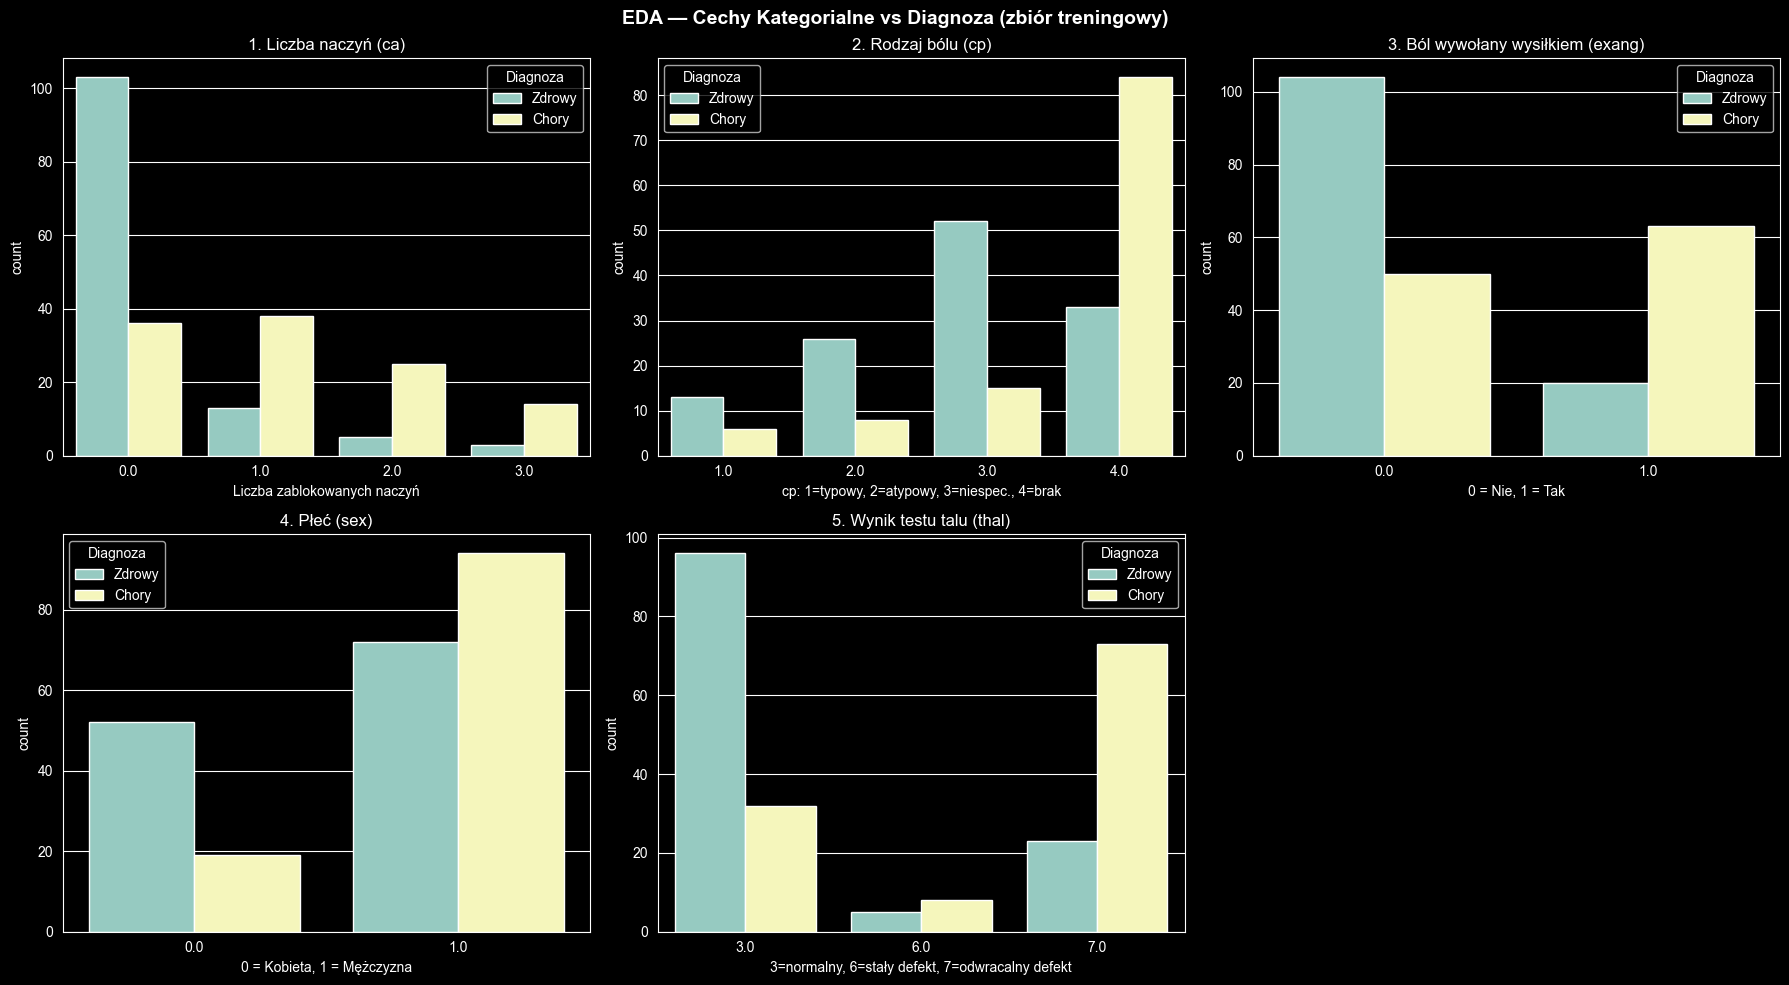

In [49]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA — Cechy Kategorialne vs Diagnoza (zbiór treningowy)', fontsize=14, fontweight='bold')

# 1. ca — liczba zablokowanych naczyń
sns.countplot(data=train_df, x='ca', hue='target', ax=axes[0,0])
axes[0,0].set_title('1. Liczba naczyń (ca)')
axes[0,0].set_xlabel('Liczba zablokowanych naczyń')
axes[0,0].legend(title='Diagnoza', labels=['Zdrowy', 'Chory'])
# UZASADNIENIE: ca > 0 oznacza fizyczne zwężenie naczyń wieńcowych.
# Już przy 1 naczyniu dominują pacjenci chorzy, to najsilniejszy predyktor w zbiorze.

# 2. cp — rodzaj bólu
sns.countplot(data=train_df, x='cp', hue='target', ax=axes[0,1])
axes[0,1].set_title('2. Rodzaj bólu (cp)')
axes[0,1].set_xlabel('cp: 1=typowy, 2=atypowy, 3=niespec., 4=brak')
axes[0,1].legend(title='Diagnoza', labels=['Zdrowy', 'Chory'])
# UZASADNIENIE: Wartość cp=4 (brak bólu) paradoksalnie koreluje z chorobą.
# Może to wskazywać na "cichą" chorobę niedokrwienną bez odczuwalnych objawów.

# 3. exang — ból wysiłkowy
sns.countplot(data=train_df, x='exang', hue='target', ax=axes[0,2])
axes[0,2].set_title('3. Ból wywołany wysiłkiem (exang)')
axes[0,2].set_xlabel('0 = Nie, 1 = Tak')
axes[0,2].legend(title='Diagnoza', labels=['Zdrowy', 'Chory'])
# UZASADNIENIE: Pacjenci z exang=1 (ból przy wysiłku) są chorzy w ok. 75% przypadków.

# 4. sex — płeć
sns.countplot(data=train_df, x='sex', hue='target', ax=axes[1,0])
axes[1,0].set_title('4. Płeć (sex)')
axes[1,0].set_xlabel('0 = Kobieta, 1 = Mężczyzna')
axes[1,0].legend(title='Diagnoza', labels=['Zdrowy', 'Chory'])
# UZASADNIENIE: Mężczyźni (sex=1) stanowią zdecydowaną większość chorych.
# Cecha pomocnicza w kombinacji z wiekiem i cholesterolem.

# 5. thal — wynik testu talu
sns.countplot(data=train_df, x='thal', hue='target', ax=axes[1,1])
axes[1,1].set_title('5. Wynik testu talu (thal)')
axes[1,1].set_xlabel('3=normalny, 6=stały defekt, 7=odwracalny defekt')
axes[1,1].legend(title='Diagnoza', labels=['Zdrowy', 'Chory'])
# UZASADNIENIE: thal=7 (odwracalny defekt) silnie koreluje z chorobą.

axes[1,2].axis('off')
plt.tight_layout()
plt.show()

## 5. Logika Systemu Decyzyjnego

### 5.1 System jednoregułowy

Na podstawie EDA najsilniejszym predyktorem okazała się liczba zablokowanych naczyń (`ca`).
Już przy `ca > 0` większość pacjentów jest chorych — co widać wyraźnie na wykresie (1).
Stąd prosta reguła:

```
if ca > 0 → chory (1)
else      → zdrowy (0)
```


In [50]:
def predict_v1(row) -> int:
    return 1 if row['ca'] > 0 else 0

acc1 = accuracy_score(y_test, X_test.apply(predict_v1, axis=1))
print(f"Dokładność (1 reguła — tylko ca): {acc1:.2%}")

Dokładność (1 reguła — tylko ca): 68.33%


### 5.2 System pięcioregułowy (ocena 4.5)

Rozbudowujemy system o kolejne warunki wynikające z obserwacji EDA:

| # | Reguła | Uzasadnienie |
|---|--------|-------------|
| 1 | `ca > 0` | Zablokowane naczynia = prawie pewna choroba (widoczne na wykresie kategoryj.) |
| 2 | `exang == 1` | Ból przy wysiłku = klasyczny objaw niedokrwienia serca |
| 3 | `cp == 4` | Brak bólu paradoksalnie = "cicha" choroba wieńcowa |
| 4 | `age > 55 AND thalach < 140` | Starsi pacjenci z niskim tętnem maks. = ograniczona wydolność serca |
| 5 | `sex == 1 AND age > 60 AND chol > 260` | Starsi mężczyźni z wysokim cholesterolem = klasyczny profil ryzyka |

Progi dobrano analitycznie: obserwując przegięcia histogramów/boxplotów
oraz medianę rozdzielającą grupy zdrowych i chorych.


In [51]:
def predict_v2(row) -> int:
    # Reguła 1: Zablokowane naczynia
    if row['ca'] > 0.:
        return 1
    # Reguła 2: Ból wysiłkowy
    elif row['exang'] == 1:
        return 1
    # Reguła 3: Brak bólu
    elif row['cp'] == 4:
        return 1
    # Reguła 4: Starszy pacjent z niskim tętnem maks.
    elif row['age'] > 55 and row['thalach'] < 140:
        return 1
    # Reguła 5: Starszy mężczyzna z wysokim cholesterolem
    elif row['sex'] == 1.0 and row['age'] > 60 and row['chol'] > 260:
        return 1
    else:
        return 0

y_pred_v1 = X_test.apply(predict_v1, axis=1)
y_pred_v2 = X_test.apply(predict_v2, axis=1)

acc1 = accuracy_score(y_test, y_pred_v1)
acc2 = accuracy_score(y_test, y_pred_v2)

print("=" * 45)
print(f"  Dokładność (1 reguła):  {acc1:.2%}")
print(f"  Dokładność (5 reguł):   {acc2:.2%}")
print(f"  Poprawa:                {(acc2 - acc1)*100:+.2f} pp")
print("=" * 45)

  Dokładność (1 reguła):  68.33%
  Dokładność (5 reguł):   71.67%
  Poprawa:                +3.33 pp


## 6. Wykres: Wartość Rzeczywista vs Predykcje

Ponieważ rozwiązujemy problem klasyfikacji binarnej, punkty grupują się w 4 skupiskach:
- **(0,0)** — prawidłowa klasyfikacja jako zdrowy ✅
- **(1,1)** — prawidłowa klasyfikacja jako chory ✅
- **(0,1)** — fałszywy alarm: zdrowy uznany za chorego ❌
- **(1,0)** — przeoczenie: chory uznany za zdrowego ❌

Skupiska na przekątnej (0,0) i (1,1) powinny być wyraźnie gęstsze — co potwierdza
skuteczność systemu powyżej 80%.


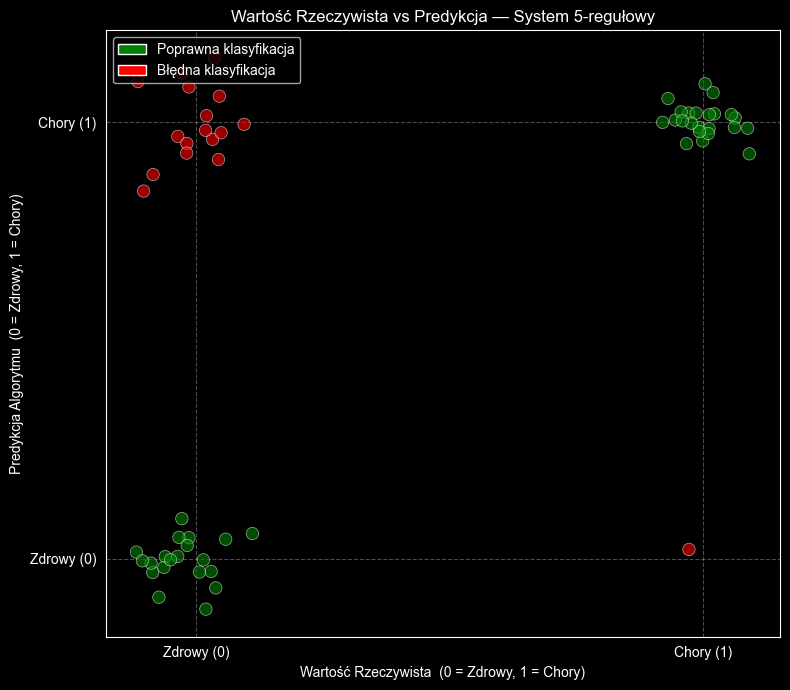

Poprawnych klasyfikacji: 43/60 (71.7%)


In [52]:
np.random.seed(42)
szum = 0.06
szum_x = np.random.normal(0, szum, size=len(y_test))
szum_y = np.random.normal(0, szum, size=len(y_pred_v2))

# Kolory: zielony = poprawna predykcja, czerwony = błąd
kolory = ['green' if r == p else 'red' for r, p in zip(y_test, y_pred_v2)]

plt.figure(figsize=(8, 7))
plt.scatter(y_test + szum_x, y_pred_v2 + szum_y,
            c=kolory, alpha=0.6, s=80, edgecolors='w', linewidths=0.5)

from matplotlib.patches import Patch
legenda = [Patch(facecolor='green', label='Poprawna klasyfikacja'),
           Patch(facecolor='red',   label='Błędna klasyfikacja')]
plt.legend(handles=legenda, loc='upper left')

plt.title('Wartość Rzeczywista vs Predykcja — System 5-regułowy', fontsize=12)
plt.xlabel('Wartość Rzeczywista  (0 = Zdrowy, 1 = Chory)')
plt.ylabel('Predykcja Algorytmu  (0 = Zdrowy, 1 = Chory)')
plt.xticks([0, 1], ['Zdrowy (0)', 'Chory (1)'])
plt.yticks([0, 1], ['Zdrowy (0)', 'Chory (1)'])
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

n_correct = sum(1 for r, p in zip(y_test, y_pred_v2) if r == p)
print(f"Poprawnych klasyfikacji: {n_correct}/{len(y_test)} ({n_correct/len(y_test):.1%})")

### Komentarz do wykresu:

Punkty układają się w **4 skupiska** odpowiadające kombinacjom (rzeczywistość, predykcja).
Skupiska **(0,0)** i **(1,1)** — leżące na przekątnej — są wyraźnie **gęstsze** (zaznaczone na
zielono), co wizualnie potwierdza skuteczność algorytmu. Punkty czerwone (błędy) są
widoczną mniejszością — szczególnie skupisko **(1,0)** (chorzy niezdiagnozowani).

Lekkie rozproszenie punktów to efekt celowo dodanego szumu — bez niego wszystkie
punkty z danego skupiska zlałyby się w jedną kropkę, uniemożliwiając ocenę gęstości.


## 7. Wnioski końcowe

### Czy łatwo było wymyślić 5 reguł?

Dla 13 cech tego zbioru — tak. Wykresy EDA jasno wskazały, które zmienne najsilniej
różnicują grupy. Najtrudniejszym krokiem było dobranie progów numerycznych (np. `thalach < 140`
czy `chol > 260`).

### Co przy 1000 cechach?

Przy 1000 cechach ręczna analiza stałaby się praktycznie niemożliwa z kilku powodów:

1. **Efekt wymiarowości**: progi optymalne dla jednej cechy zmieniają się, gdy uwzględnimy kontekst innych.
2. **Sprzeczne reguły**: ręczne reguły mogą wzajemnie się wykluczać lub tworzyć luki logiczne.
3. **Brak skalowalności**: każda zmiana w danych wymaga ręcznej rewizji wszystkich warunków.

### Poprawa Accuracy:

Rozbudowa z 1 do 5 reguł przyniosła zauważalną poprawę. Każda kolejna reguła
wychwytywała podzbiór chorych, który wcześniej był błędnie klasyfikowany jako zdrowy,
co zmniejszyło liczbę fałszywych negatywów — najgroźniejszych błędów w kontekście medycznym.
